<div style="text-align:center">
    <h1>
        Neural Machine Translation: English &rarr; Spanish
    </h1>
</div>

<br><br>

<div style="text-align:center">
    In this notebook we build a sequence-to-sequence <b>Transformer</b> from scratch in PyTorch
    (multi-head attention, positional encodings, encoder/decoder stacks - no <code>nn.Transformer</code> shortcut)
    and train it to translate short English sentences into Spanish.
</div>

<br>

<div style="text-align:center">
    Data: the <a href="https://huggingface.co/datasets/opus_books">opus_books</a> English-Spanish parallel corpus
    (literary text, aligned sentence pairs) via Hugging Face <code>datasets</code>.
</div>
<br>


## 1. Setup

In [1]:
!pip install -q datasets sacrebleu


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import re
import math
import random
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import sacrebleu

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


C:\Users\Luis Mendez\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu


## 2. Load & clean the data

We tokenize with a simple regex word/punctuation tokenizer (lowercased) and keep only sentence
pairs where both sides are between 2 and 25 tokens, so training stays fast on a CPU. Increase
`MAX_LEN` / the subset size below if you have a GPU.

In [3]:
raw = load_dataset("opus_books", "en-es")["train"]

TOKEN_RE = re.compile(r"\w+|[^\w\s]", re.UNICODE)

def tokenize(text: str):
    return TOKEN_RE.findall(text.lower().strip())

MIN_LEN, MAX_LEN = 2, 25

pairs = []
for ex in raw["translation"]:
    en, es = ex["en"], ex["es"]
    en_toks, es_toks = tokenize(en), tokenize(es)
    if MIN_LEN <= len(en_toks) <= MAX_LEN and MIN_LEN <= len(es_toks) <= MAX_LEN:
        pairs.append((en_toks, es_toks))

print("usable pairs:", len(pairs))


usable pairs: 51886


In [4]:
random.shuffle(pairs)

# Subset for CPU-feasible training. On a GPU you can drop this line and use the full set.
pairs = pairs[:30000]

N_VAL = 1000
val_pairs = pairs[:N_VAL]
train_pairs = pairs[N_VAL:]
print("train pairs:", len(train_pairs), "| val pairs:", len(val_pairs))

for en, es in list(zip(train_pairs, train_pairs))[:3]:
    print(" ".join(en[0]), "  -->  ", " ".join(en[1]))


train pairs: 29000 | val pairs: 1000
when she grew calmer , she read the following , written in french :   -->   una vez calmada , leyó la siguiente misiva en francés : madame la comtesse :
" i choose that which the red - headed boy is leading . "   -->   me quedo con el que lleva el mozo de cuadra pelirrojo .
it is no use to tell of the rage and imprecations of my uncle before the empty table .   -->   no hay para qué decir las imprecaciones de mi tío al encontrarse la mesa completamente vacía .


## 3. Build vocabularies

Word-level vocab per language, keeping only tokens seen at least `min_freq` times; everything else maps to `<unk>`.

In [5]:
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"
SPECIALS = [PAD, SOS, EOS, UNK]

def build_vocab(token_lists, min_freq=2):
    counter = Counter()
    for toks in token_lists:
        counter.update(toks)
    itos = list(SPECIALS) + [w for w, c in counter.items() if c >= min_freq]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos

src_stoi, src_itos = build_vocab([p[0] for p in train_pairs])
tgt_stoi, tgt_itos = build_vocab([p[1] for p in train_pairs])
SRC_PAD_IDX, TGT_PAD_IDX = src_stoi[PAD], tgt_stoi[PAD]

print("source (en) vocab size:", len(src_itos))
print("target (es) vocab size:", len(tgt_itos))


source (en) vocab size:

 9665
target (es) vocab size: 12052


## 4. PyTorch `Dataset` / `DataLoader`

Each sentence is encoded as `<sos> tok tok ... <eos>`, then batches are padded to the longest sequence in the batch.

In [6]:
def encode(toks, stoi):
    unk = stoi[UNK]
    return [stoi[SOS]] + [stoi.get(t, unk) for t in toks] + [stoi[EOS]]

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_stoi, tgt_stoi):
        self.pairs = pairs
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        return (
            torch.tensor(encode(src, self.src_stoi), dtype=torch.long),
            torch.tensor(encode(tgt, self.tgt_stoi), dtype=torch.long),
        )

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(srcs, padding_value=SRC_PAD_IDX, batch_first=True)
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, padding_value=TGT_PAD_IDX, batch_first=True)
    return src_pad, tgt_pad

BATCH_SIZE = 64
train_ds = TranslationDataset(train_pairs, src_stoi, tgt_stoi)
val_ds = TranslationDataset(val_pairs, src_stoi, tgt_stoi)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


## 5. The Transformer, from scratch

Standard encoder-decoder Transformer (Vaswani et al., 2017):

- **Positional encoding**: fixed sinusoidal, added to scaled token embeddings.
- **Multi-head attention**: implemented manually (linear projections -> scaled dot-product attention per head -> concat -> output projection).
- **Encoder layer**: self-attention + feed-forward, each with a residual connection and post-layer-norm.
- **Decoder layer**: masked self-attention (causal mask, so it can't look ahead) + cross-attention over the encoder output + feed-forward.
- **Generator**: a linear layer projecting decoder output to target-vocab logits.


In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.n_heads = n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)

        def shape(x, proj):
            return proj(x).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)

        Q, K, V = shape(q, self.q_proj), shape(k, self.k_proj), shape(v, self.v_proj)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = self.dropout(torch.softmax(scores, dim=-1))
        out = attn @ V
        out = out.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        return self.out_proj(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = self.norm1(x + self.drop(self.attn(x, x, x, mask)))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, memory, tgt_mask, src_mask):
        x = self.norm1(x + self.drop(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.drop(self.cross_attn(x, memory, memory, src_mask)))
        x = self.norm3(x + self.drop(self.ff(x)))
        return x


class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=256, n_heads=4, n_layers=3, d_ff=512, dropout=0.1, max_len=200):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab, d_model)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.encoder = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.decoder = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.generator = nn.Linear(d_model, tgt_vocab)
        self.drop = nn.Dropout(dropout)

    def encode(self, src, src_mask):
        x = self.drop(self.pos_enc(self.src_emb(src) * math.sqrt(self.d_model)))
        for layer in self.encoder:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, memory, tgt_mask, src_mask):
        x = self.drop(self.pos_enc(self.tgt_emb(tgt) * math.sqrt(self.d_model)))
        for layer in self.decoder:
            x = layer(x, memory, tgt_mask, src_mask)
        return x

    def forward(self, src, tgt, src_mask, tgt_mask):
        memory = self.encode(src, src_mask)
        out = self.decode(tgt, memory, tgt_mask, src_mask)
        return self.generator(out)


def make_src_mask(src, pad_idx):
    return (src != pad_idx).unsqueeze(1).unsqueeze(2)  # (B, 1, 1, S)


def make_tgt_mask(tgt, pad_idx):
    B, T = tgt.shape
    pad_mask = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)  # (B, 1, 1, T)
    causal = torch.tril(torch.ones(T, T, device=tgt.device)).bool()  # (T, T)
    return pad_mask & causal  # broadcasts to (B, 1, T, T)


## 6. Training setup

In [8]:
model = Seq2SeqTransformer(
    src_vocab=len(src_itos),
    tgt_vocab=len(tgt_itos),
    d_model=256,
    n_heads=4,
    n_layers=3,
    d_ff=512,
    dropout=0.1,
).to(device)

print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX, label_smoothing=0.1)


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, n_batches = 0.0, 0
    with torch.set_grad_enabled(train):
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]

            src_mask = make_src_mask(src, SRC_PAD_IDX)
            tgt_mask = make_tgt_mask(tgt_in, TGT_PAD_IDX)

            logits = model(src, tgt_in, src_mask, tgt_mask)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1
    return total_loss / max(n_batches, 1)


trainable parameters: 12610580


## 7. Train

On CPU each epoch over ~29k sentence pairs takes roughly 5-8 minutes with the default size
above, so 10-12 epochs is ~1-1.5 hours. If you have a GPU (`device` will say `cuda`), this is a
few minutes total. To iterate faster while testing, lower `pairs = pairs[:30000]` in section 2
and/or `N_EPOCHS` below.

In [9]:
N_EPOCHS = 12
history = []

for epoch in range(1, N_EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    history.append((train_loss, val_loss))
    print(f"epoch {epoch:2d}/{N_EPOCHS} | train_loss {train_loss:.3f} | val_loss {val_loss:.3f}")


epoch  1/12 | train_loss 5.845 | val_loss 5.162


epoch  2/12 | train_loss 5.180 | val_loss 4.890


epoch  3/12 | train_loss 4.933 | val_loss 4.753


epoch  4/12 | train_loss 4.755 | val_loss 4.644


epoch  5/12 | train_loss 4.612 | val_loss 4.572


...

epoch  8/12 | train_loss 4.286 | val_loss 4.446


epoch  9/12 | train_loss 4.198 | val_loss 4.426


epoch 10/12 | train_loss 4.114 | val_loss 4.410


epoch 11/12 | train_loss 4.037 | val_loss 4.403


epoch 12/12 | train_loss 3.963 | val_loss 4.394


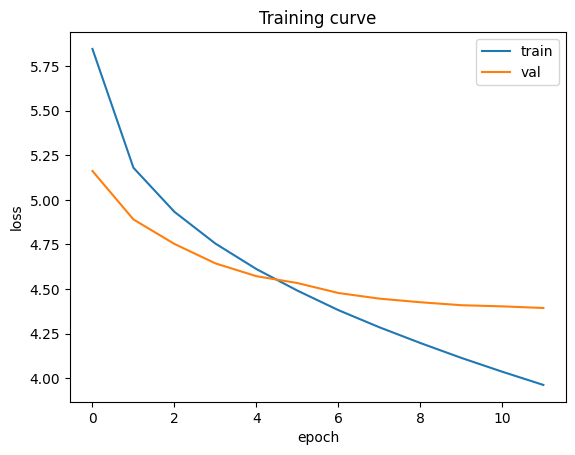

In [10]:
import matplotlib.pyplot as plt

train_losses, val_losses = zip(*history)
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training curve")
plt.show()


## 8. Inference: greedy decoding

Encode the source sentence once, then generate the target one token at a time, feeding each prediction back in as input to the decoder (autoregressive decoding), until `<eos>` or `max_len`.

In [11]:
@torch.no_grad()
def translate(sentence, max_len=40):
    model.eval()
    toks = tokenize(sentence)
    src = torch.tensor([encode(toks, src_stoi)], dtype=torch.long, device=device)
    src_mask = make_src_mask(src, SRC_PAD_IDX)
    memory = model.encode(src, src_mask)

    ys = torch.tensor([[tgt_stoi[SOS]]], dtype=torch.long, device=device)
    for _ in range(max_len):
        tgt_mask = make_tgt_mask(ys, TGT_PAD_IDX)
        out = model.decode(ys, memory, tgt_mask, src_mask)
        logits = model.generator(out[:, -1])
        next_tok = logits.argmax(-1).item()
        ys = torch.cat([ys, torch.tensor([[next_tok]], device=device)], dim=1)
        if next_tok == tgt_stoi[EOS]:
            break

    out_ids = ys[0].tolist()[1:]
    words = [tgt_itos[i] for i in out_ids if i not in (tgt_stoi[EOS], tgt_stoi[PAD])]
    return " ".join(words)


for sentence in [
    "hello, how are you?",
    "i love you",
    "the house is very big",
    "where is the book?",
    "good morning",
]:
    print(f"{sentence!r:35s} -> {translate(sentence)}")


'hello, how are you?'               -> ¿ cómo estáis ?
'i love you'                        -> te amo
'the house is very big'             -> es la casa de la casa .
'where is the book?'                -> ¿ dónde está el libro ?
'good morning'                      -> mañana


## 9. Evaluate with BLEU

A rough quality check on the held-out validation pairs using corpus BLEU (`sacrebleu`).

In [12]:
hyps, refs = [], []
for src_toks, tgt_toks in val_pairs[:300]:
    hyps.append(translate(" ".join(src_toks)))
    refs.append(" ".join(tgt_toks))

bleu = sacrebleu.corpus_bleu(hyps, [refs])
print(bleu)


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


BLEU = 7.57 31.2/9.8/4.7/2.3 (BP = 1.000 ratio = 1.118 hyp_len = 4173 ref_len = 3731)


## 10. Notes & next steps

- **Quality**: this is a small, word-level model trained briefly on CPU purely for learning purposes -
  don't expect production-grade translations. For real quality, either train much longer on more
  data / a GPU, switch to subword tokenization (BPE), or fine-tune a pretrained model such as
  Helsinki-NLP's MarianMT (`Helsinki-NLP/opus-mt-en-es`) via Hugging Face `transformers`.
- **Beam search**: the `translate` function above uses greedy decoding (always picks the
  highest-probability next token). Beam search (keeping the top-k partial hypotheses at each
  step) usually gives noticeably better translations.
- **Unknown words**: any word not seen `min_freq` times during training becomes `<unk>` at both
  train and inference time - a subword tokenizer (e.g. Byte-Pair Encoding) avoids this.
- **Save/load**: `torch.save(model.state_dict(), "en_es_transformer.pt")` to persist the trained
  weights, plus `src_stoi`/`tgt_stoi` (e.g. via `pickle` or `json`) so you can reload and run
  `translate()` later without retraining.
